In [1]:
import radmc3d_tools
import radmc3dPy
import numpy as np
import matplotlib.pyplot as plt
SMALL_SIZE = 13
MEDIUM_SIZE = 15
BIGGER_SIZE = 20

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

Fast (Fortran90) Mie-scattering module could not be imported. Falling back to the slower Python version.


# Load images

In [2]:
import os
# so it can find Radmc3D
os.environ["PATH"] += ":/home/hd/hd_hd/hd_cu284/bin"
# so it can find other libraries Radmc3D depends on that I cannot access from inside the singularity container.
# DO NOT TOUCH!!!!
os.environ["LD_LIBRARY_PATH"] = "/home/hd/hd_hd/hd_cu284/libs:" + os.environ.get("LD_LIBRARY_PATH", "")
# Change path to dir that contains all the radmc3d-relevant files, like dust_density.inp etc.
os.chdir("/home/hd/hd_hd/hd_cu284/jupyter notebooks/thesis_suited_plots_maybe/radmc3d_sims")
# Don't touch. 

###### REMEMBER TO CHECK PATH ########

In [13]:
incl = 45.0
posang = 356.+90
npix = 400
sizeau = 800
phi_ang= 180 # does not do that much
wav_K = 2.2 # K band
wav_H = 1.65 # H band

path_start = f"/pfs/10/work/hd_cu284-work/fargo3d/outputs/"
path_endings=["fargo_fiducial_2gen", "fargo_high_mass_2gen",  "fargo_low_mass_2gen", "fargo_high_visc_2gen", "fargo_low_visc_2gen",
              "fargo_sigslop_0_2gen","fargo_sigslop_0.5_2gen", "fargo_sigslop_-2_2gen","fargo_sigslop_1.5_2gen", ]
sigslopes = np.array([1,1,1,1,1,0,0.5,-2,1.5])



titles = ["fiducial", "$M_p = 10 M_{jup}$", "$M_p = 2 M_{Jup}$", "$\\alpha = 10^{-2}$", "$\\alpha = 10^{-4}$", "$\\gamma = 0$",
          "$\\gamma = 0.5$", "$\\gamma = -2$", "$\\gamma = 1.5$"]
paths = []
for i in range(len(path_endings)):
    paths.append(path_start+path_endings[i])
len(paths)

9

In [4]:
import numpy as np
from radmc3dPy.image import makeImage, plotImage

images_K = np.load("radmc3d_imgs_redone/images_K_dens_1.npy", allow_pickle=True)
sigmeans = np.load("radmc3d_imgs_redone/sigmameans_dens_1.npy", allow_pickle=True)
dens = np.load("radmc3d_imgs_redone/dens_dens_1.npy", allow_pickle=True)
#images_K = np.load("images_K_run_2.npy", allow_pickle=True)
#images_K = np.load("images_K_zoomed_in.npy", allow_pickle=True)
#sigmeans = np.load("sigmameans_run_2.npy", allow_pickle=True)
#sigmeans = np.load("sigmameans_zoomed_in.npy", allow_pickle=True)

In [2]:
log_img_data = []
lin_img_data= []
for i,path in enumerate(paths[:]):
    #if i == 7:
    #    continue
    print(f"#########################\n{path[43:-5]} images:\n#########################")
    result=plotImage(images_K[i],log=True, maxlog=4)
    img = result["implot"]
    data = img.get_array()
    log_img_data.append(data)
    #result = plotImage(images_K[i],log=False, saturate=0.01)
    #data = img.get_array()
    #lin_img_data.append(data)


NameError: name 'paths' is not defined

# Test: deprojecting the image

(400, 400)


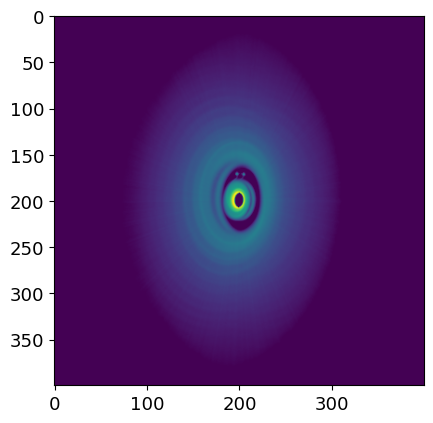

In [6]:
img = result["implot"]
data = img.get_array()
plt.imshow(data)
print(data.shape)

0.7071067811865475


(-400.0, 400.0)

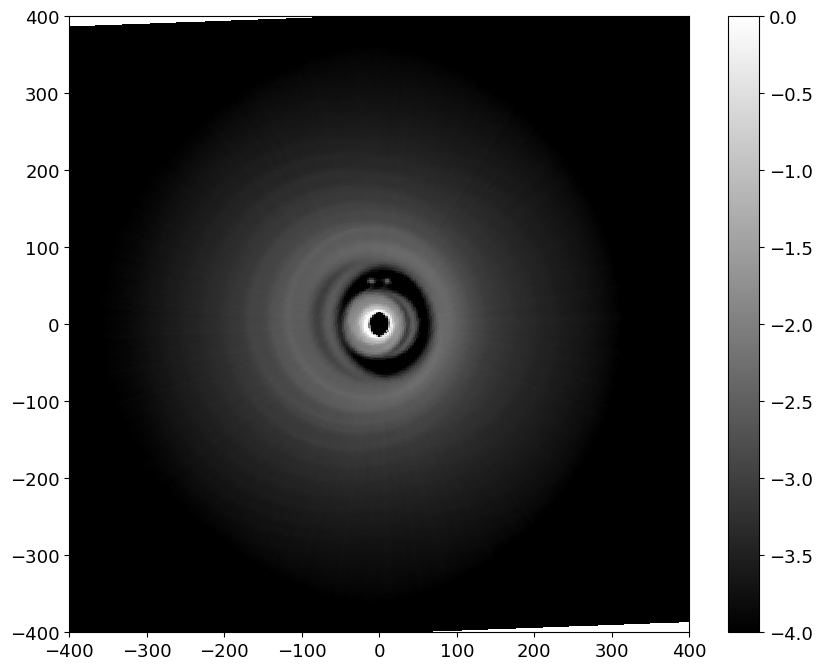

In [7]:
incl = 45.0
posang = -(357.+90)
posang_rad = posang/360*2*np.pi
incl_rad = incl/360*2*np.pi

x= np.linspace(-sizeau/2, sizeau/2, npix)
y = np.linspace(-sizeau/2, sizeau/2, npix)

X, Y = np.meshgrid(x, y, indexing='ij')

XX = X*np.cos(posang_rad)-Y*np.sin(posang_rad)
YY = X*np.sin(posang_rad)+Y*np.cos(posang_rad)

XXX= XX/np.sin(incl_rad)
print(np.sin(incl_rad))
YYY = YY

plt.figure(figsize=(10,8))
plt.pcolormesh(XXX, YYY,data, cmap="grey")
plt.colorbar()
plt.xlim(-400,400)
plt.ylim(-400,400)

(6, 7) (6, 7) (6, 7)


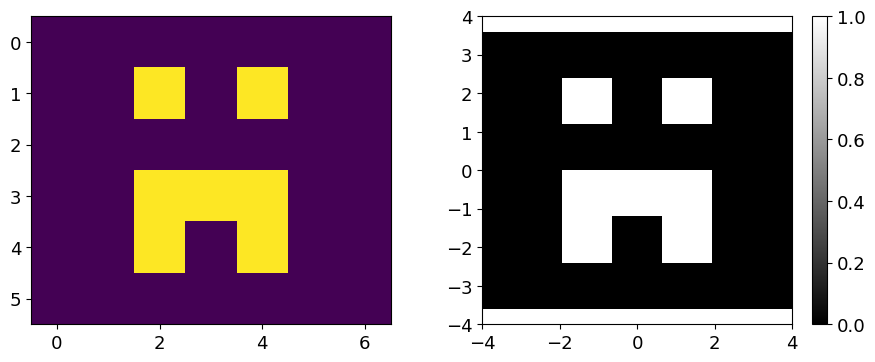

In [17]:
img = np.array([[0,0,0,0,0,0,0],[0,0,1,0,1,0,0],[0,0,0,0,0,0,0],[0,0,1,1,1,0,0],[0,0,1,0,1,0,0],[0,0,0,0,0,0,0]])

xx = np.linspace(-3,3,6)
yy = np.linspace(-1,1,7)

X, Y = np.meshgrid(xx, yy, indexing='ij')


ang = np.pi/2
XX= np.cos(ang)*X + np.sin(ang)*Y
YY = -np.sin(ang)*X+np.cos(ang)*Y

ang2 = 75/180*np.pi

XXX= XX/np.cos(ang2)
YYY = YY


print(X.shape, Y.shape, img.shape)

plt.figure(figsize=(11,4))
plt.subplot(1,2,1)
plt.imshow(img)
plt.subplot(1,2,2)
plt.pcolormesh(XXX,YYY,img,cmap="grey")
plt.xlim(-4,4)
plt.ylim(-4,4)

plt.colorbar()

# Densities

Text(0.5, 1.0, 'Dust density')

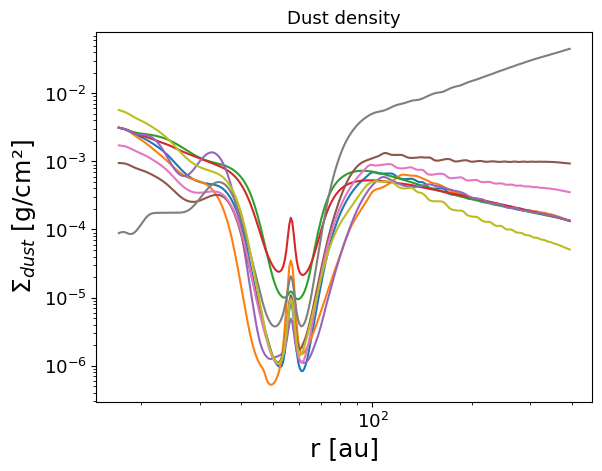

In [13]:
r_list = np.fromfile(f"{path}/domain_y.dat", sep="\n")[3:-4]
for i,path in enumerate(paths):
    plt.plot(r_list*57, sigmeans[i], label=f"{path[43:-5]}")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("r [au]")
plt.ylabel("$\\Sigma_{dust}$ [g/cm²]")
plt.title("Dust density")

# Deprojecting all images.

In [11]:
def plot_deprojected(data,incl = 45.0,posang = -(357.+90), clim=None):
    posang_rad = posang/360*2*np.pi
    incl_rad = incl/360*2*np.pi
    
    x= np.linspace(-sizeau/2, sizeau/2, npix)
    y = np.linspace(-sizeau/2, sizeau/2, npix)
    
    X, Y = np.meshgrid(x, y, indexing='ij')
    
    XX = X*np.cos(posang_rad)-Y*np.sin(posang_rad)
    YY = X*np.sin(posang_rad)+Y*np.cos(posang_rad)
    
    XXX= XX/np.sin(incl_rad)
    YYY = YY
    
    plt.figure(figsize=(10,8))
    plt.pcolormesh(XXX, YYY,data, cmap="grey", clim=clim)
    plt.colorbar()
    plt.xlim(-200,200)
    plt.ylim(-200,200)

In [ ]:
clim_up = np.ones(9)*0.01
clim_up[5] = 0.05
clim_up[6] = 0.02
clim_up[7] = 0.3
for i,path in enumerate(paths[:]):
    plot_deprojected(np.power(10,log_img_data[i]), clim=(0,clim_up[i]))
    plt.title(path[43:-5])
    

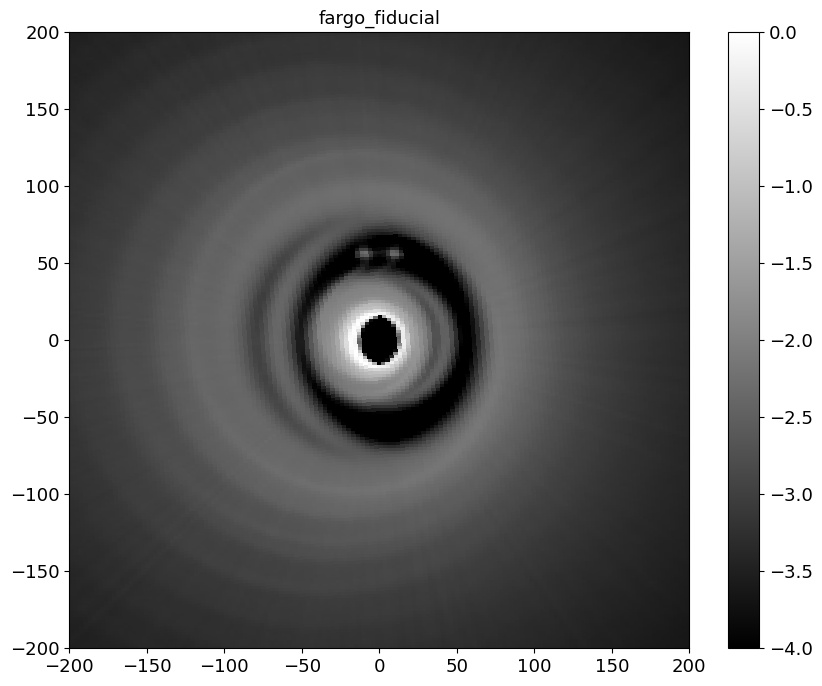

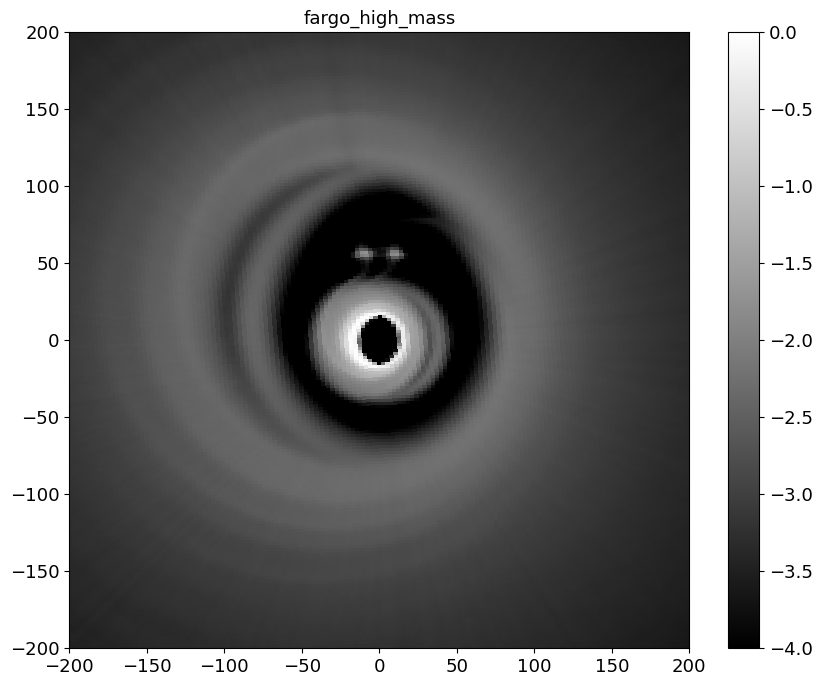

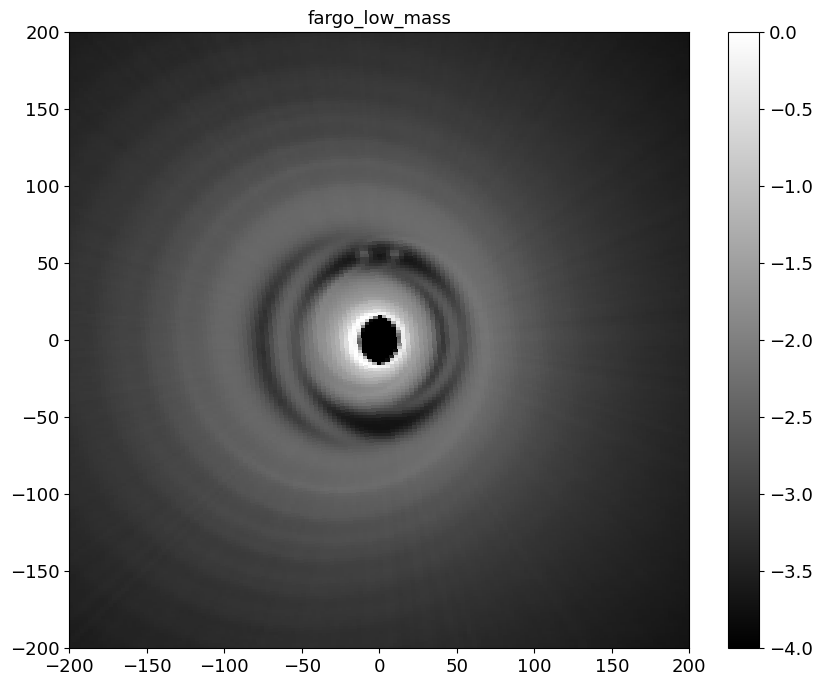

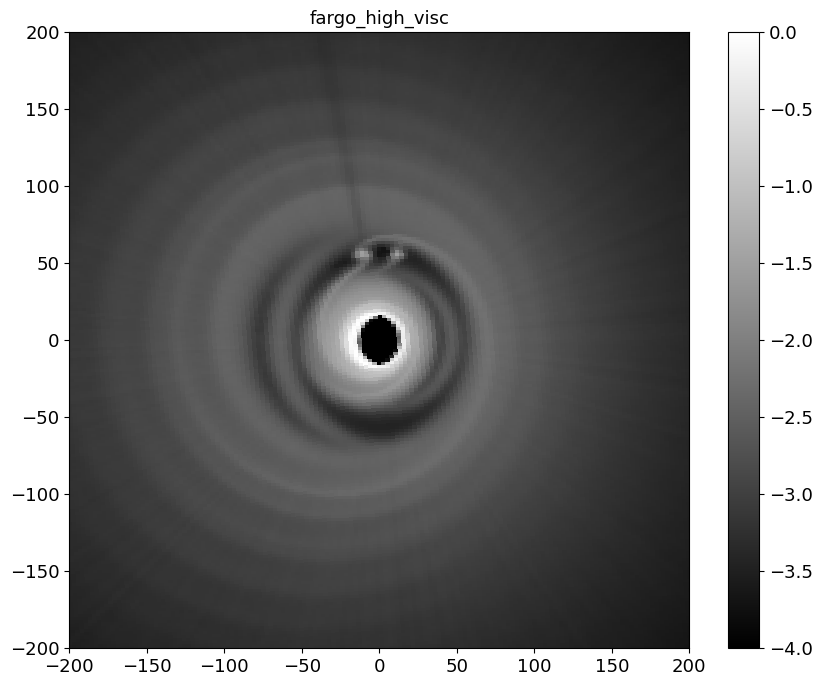

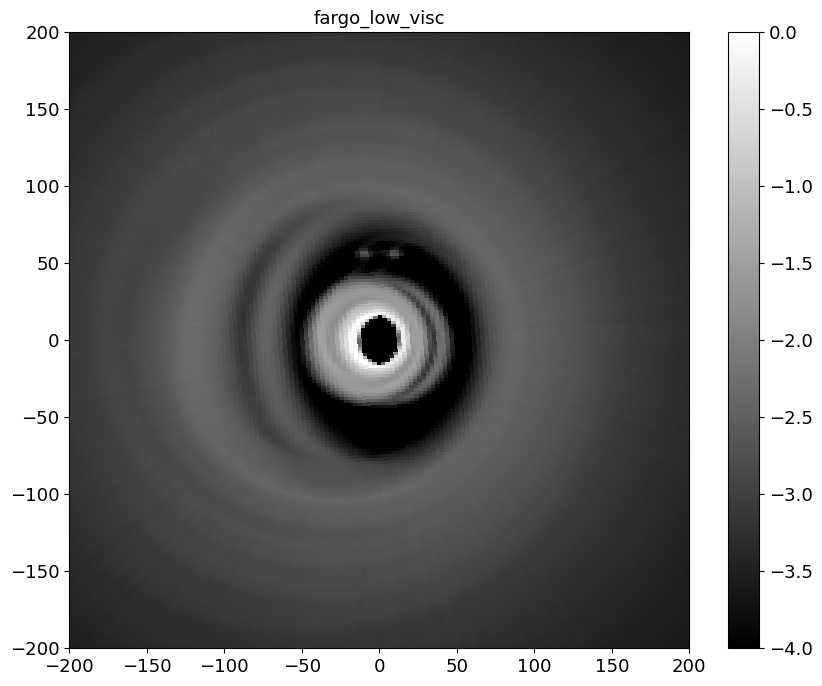

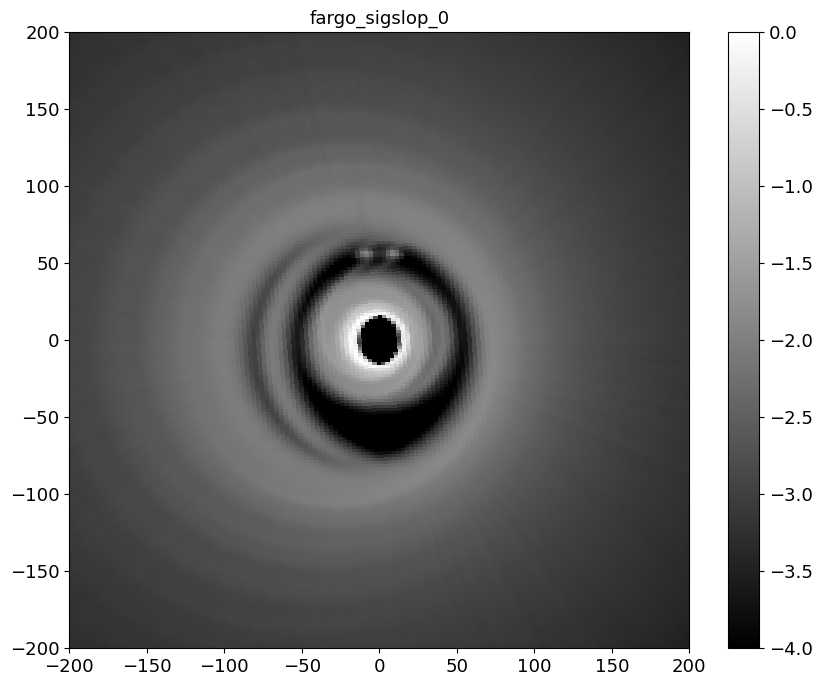

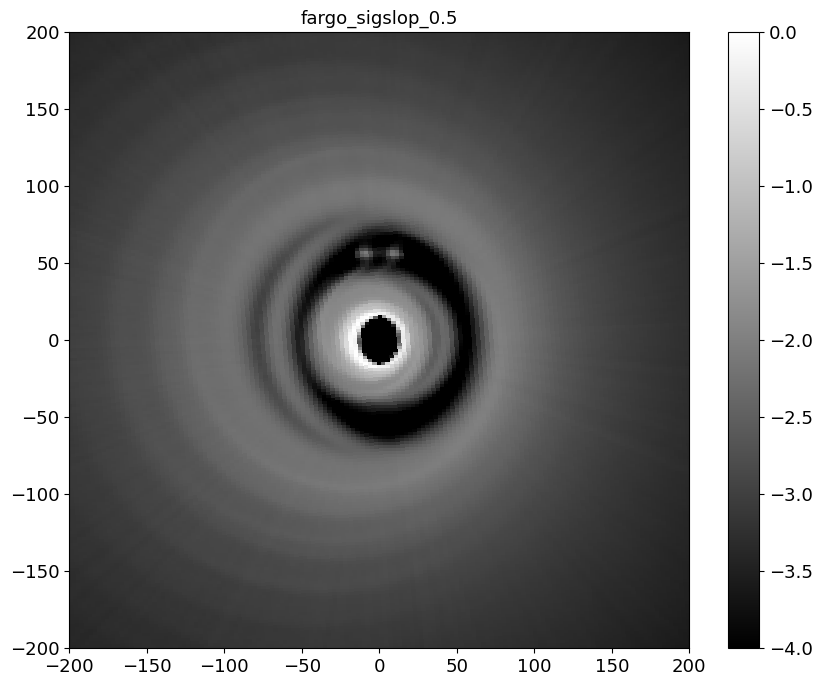

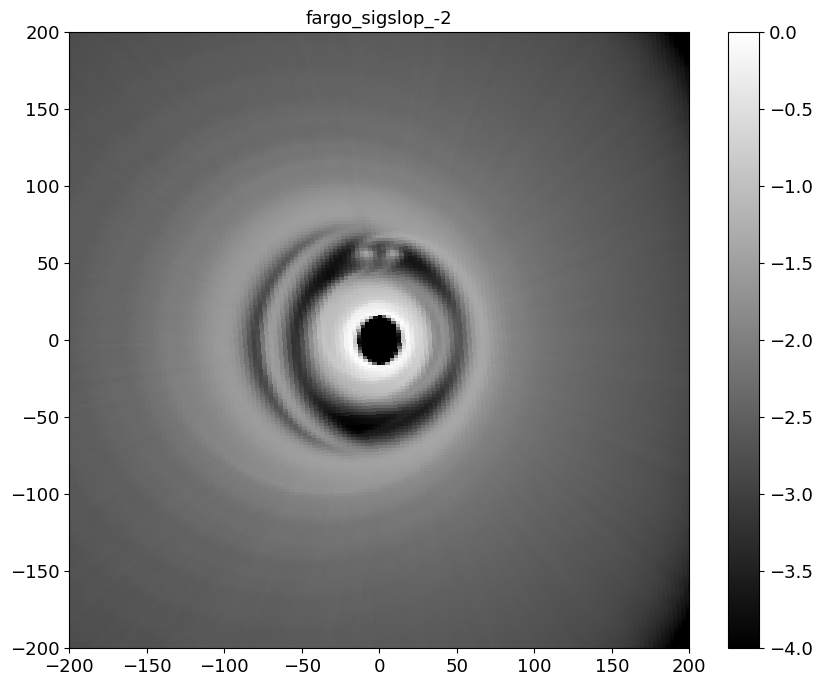

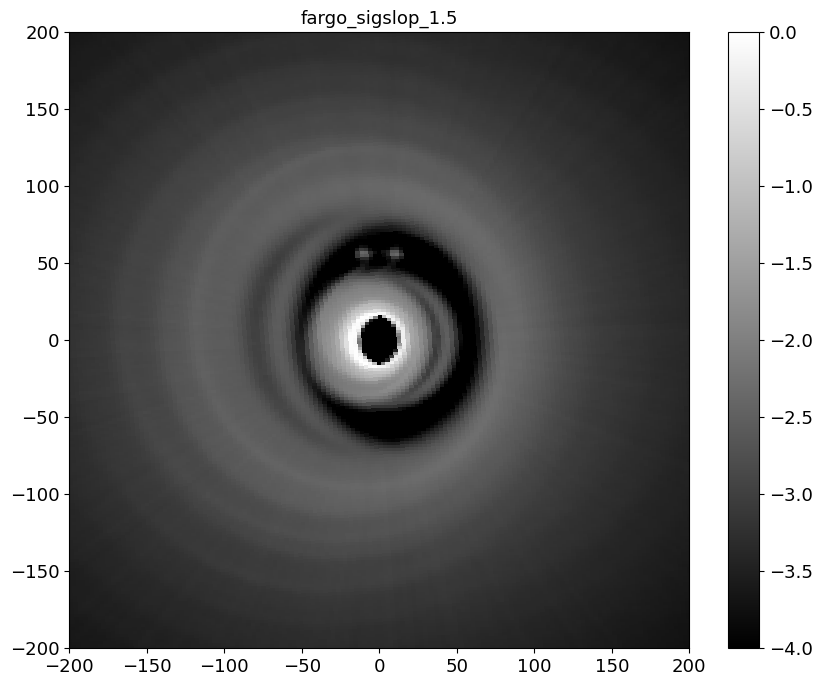

In [12]:

for i,path in enumerate(paths[:]):
    plot_deprojected(log_img_data[i])
    plt.title(path[43:-5])
    

r_in: 74.28050637178106
r_out: 76.01072163330947
Eccentricity for fargo_low_mass: 0.01151241682228992
r_in: 78.68190308236443
r_out: 90.33891197028348
Eccentricity for fargo_fiducial: 0.06896788945366306
r_in: 84.30917812558782
r_out: 113.72995195322613
Eccentricity for fargo_high_mass: 0.14856040730904888


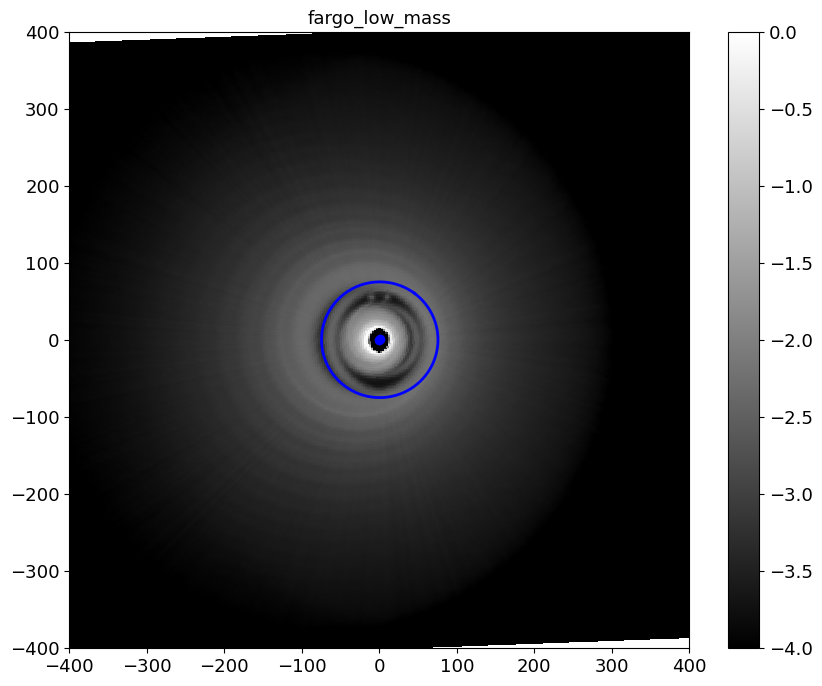

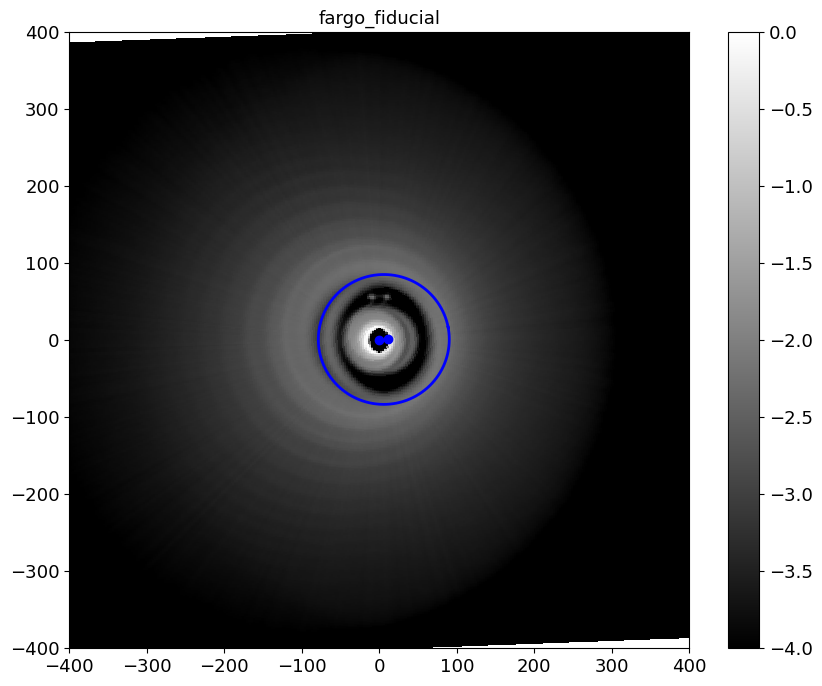

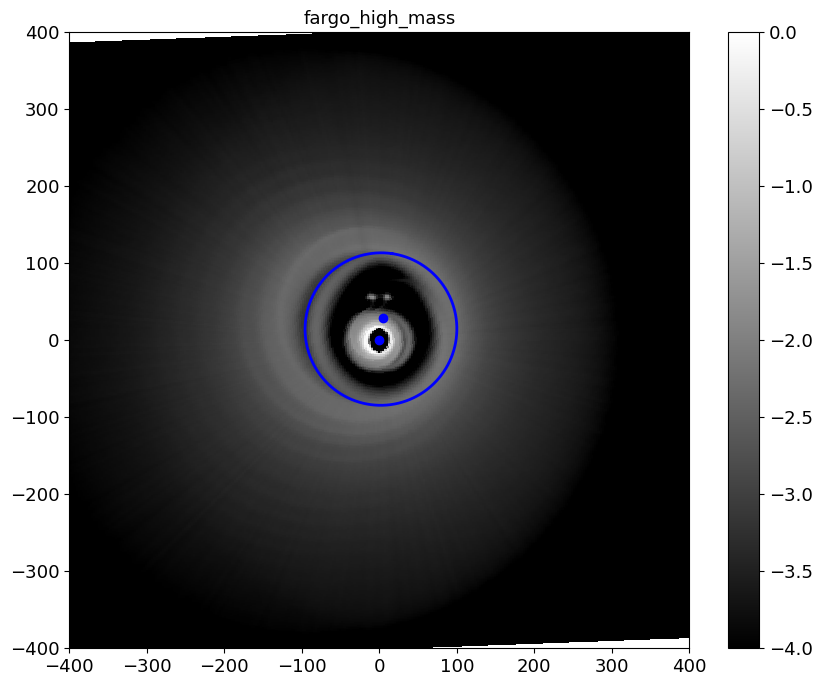

In [28]:

index_for_mass=[2,0,1]

r_in_log = [0.115,0.14,0.17]
r_out_log = [0.125,0.20,0.30]
phi_ellipse = np.array([2.5,4.9-np.pi,3.0])#+np.pi/2




for it, i in enumerate(index_for_mass):
    #plot_deprojected(np.power(10,log_img_data[i]), clim=(0,clim_up[i]))
    plot_deprojected(log_img_data[i], clim=(-4,0))
    #plot_deprojected(log_img_data[i])
    plt.title(paths[i][43:-5])

    r_in = np.power(10,r_in_log[it])*57
    r_out = np.power(10,r_out_log[it])*57

    a = (r_in+r_out)/2
    e = (r_out-r_in)/2
    b = np.sqrt(a**2-e**2)
    print(f"r_in: {r_in}\nr_out: {r_out}")
    path = paths[i]
    print(f"Eccentricity for {path[43:-5]}: {e/a}")
    
    centerx = e
    centery = 0
    philist = np.linspace(0,2*np.pi,360)
    
    x_ell_ = centerx + a*np.cos(philist)
    y_ell_ = centery + b*np.sin(philist)
    
    phi = phi_ellipse[it]-np.pi/2
    x_ell = x_ell_*np.cos(phi) - y_ell_*np.sin(phi)
    y_ell = +x_ell_*np.sin(phi) + y_ell_*np.cos(phi)
    
    plt.plot(x_ell,y_ell, linewidth=2, color="blue")
    plt.scatter([0,2*e*np.cos(phi)],[0,2*e*np.sin(phi)], zorder=3, color="blue")

r_in: 87.27198531587571
r_out: 99.0546472387144
Eccentricity for fargo_low_visc: 0.06323659565621459
r_in: 78.68190308236443
r_out: 90.33891197028348
Eccentricity for fargo_fiducial: 0.06896788945366306
r_in: 76.89088430772425
r_out: 81.44695563513287
Eccentricity for fargo_high_visc: 0.02877436833199738


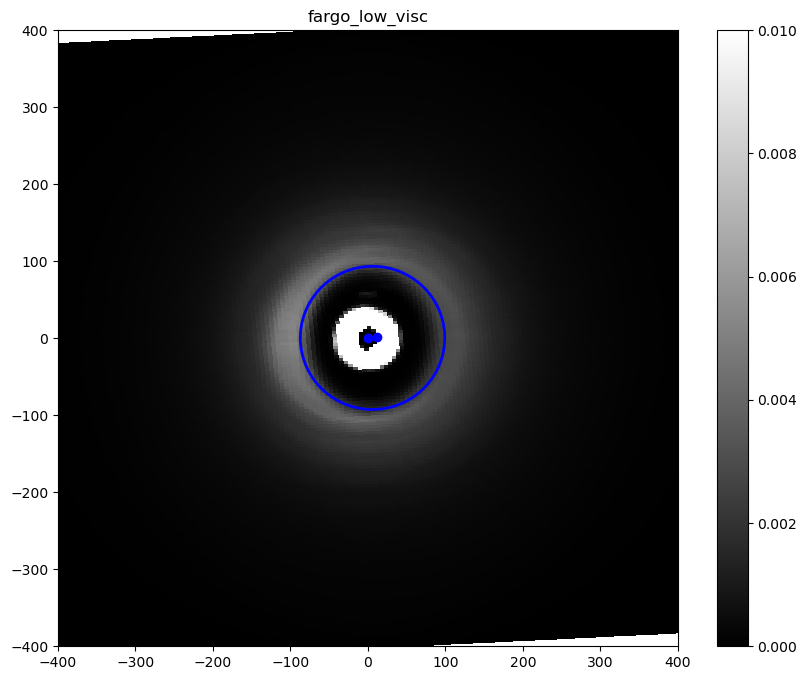

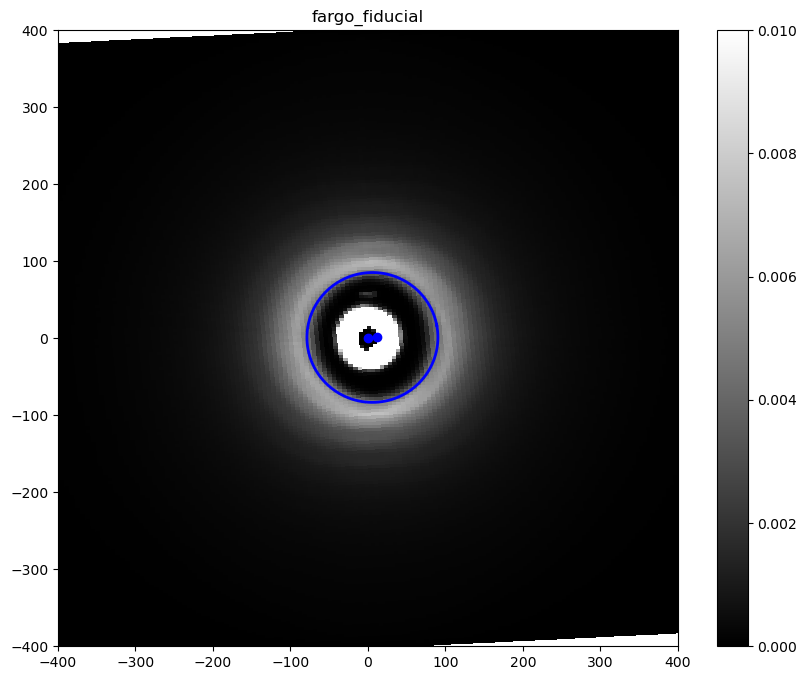

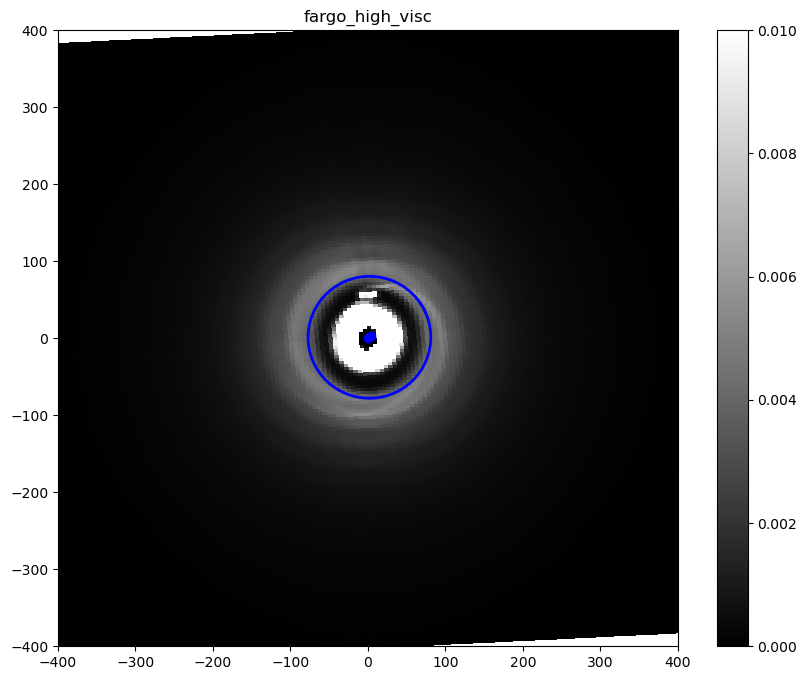

In [168]:

index_for_visc=[4,0,3]

r_in_log = [0.185,0.14,0.13]
r_out_log = [0.24,0.20,0.155]
phi_ellipse = [4.8-np.pi,4.9-np.pi,5.3-np.pi]


lim = 0.003

for it, i in enumerate(index_for_visc):
    plot_deprojected(np.power(10,log_img_data[i]), clim=(0,clim_up[i])) #clim=(lim-1e-4,lim+1e-4))#
    #plot_deprojected(log_img_data[i])
    
    plt.title(paths[i][43:-5])

    r_in = np.power(10,r_in_log[it])*57
    r_out = np.power(10,r_out_log[it])*57

    a = (r_in+r_out)/2
    e = (r_out-r_in)/2
    b = np.sqrt(a**2-e**2)
    print(f"r_in: {r_in}\nr_out: {r_out}")
    path = paths[i]
    print(f"Eccentricity for {path[43:-5]}: {e/a}")
    
    centerx = e
    centery = 0
    philist = np.linspace(0,2*np.pi,360)
    
    x_ell_ = centerx + a*np.cos(philist)
    y_ell_ = centery + b*np.sin(philist)
    
    phi = phi_ellipse[it]-np.pi/2
    x_ell = x_ell_*np.cos(phi) - y_ell_*np.sin(phi)
    y_ell = +x_ell_*np.sin(phi) + y_ell_*np.cos(phi)
    
    plt.plot(x_ell,y_ell, linewidth=2, color="blue")
    plt.scatter([0,2*e*np.cos(phi)],[0,2*e*np.sin(phi)], zorder=3, color="blue")

r_in: 78.68190308236443
r_out: 93.51361707237375
Eccentricity for fargo_sigslop_1.5: 0.0861329840444238
r_in: 78.68190308236443
r_out: 90.33891197028348
Eccentricity for fargo_fiducial: 0.06896788945366306
r_in: 77.78123878556869
r_out: 90.33891197028348
Eccentricity for fargo_sigslop_0.5: 0.07469463433298558
r_in: 76.01072163330947
r_out: 89.30481099616449
Eccentricity for fargo_sigslop_0: 0.08041645664749124


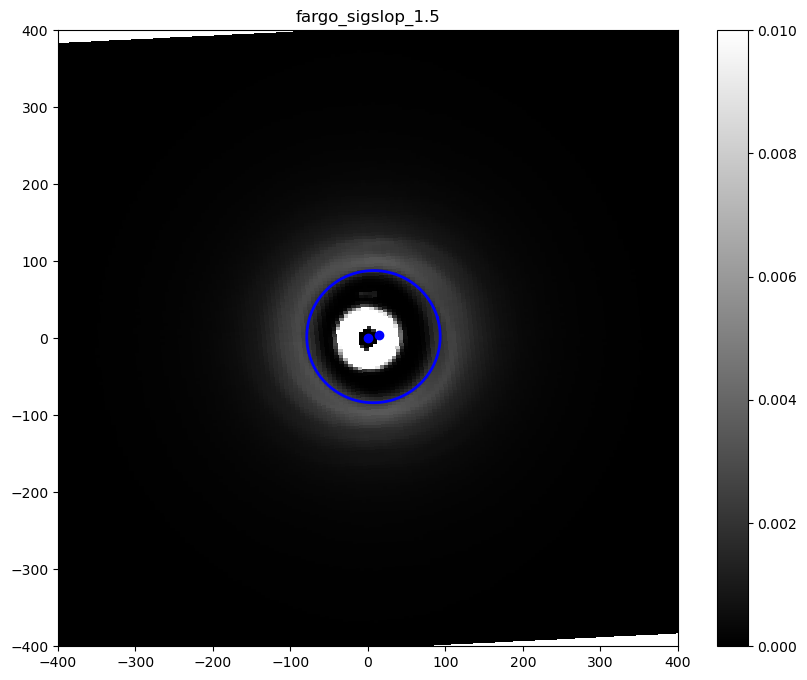

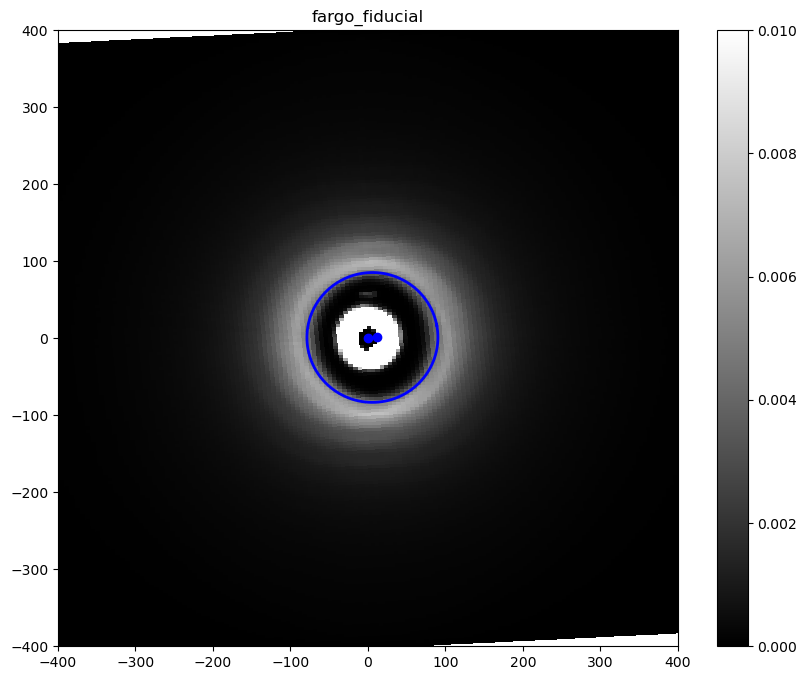

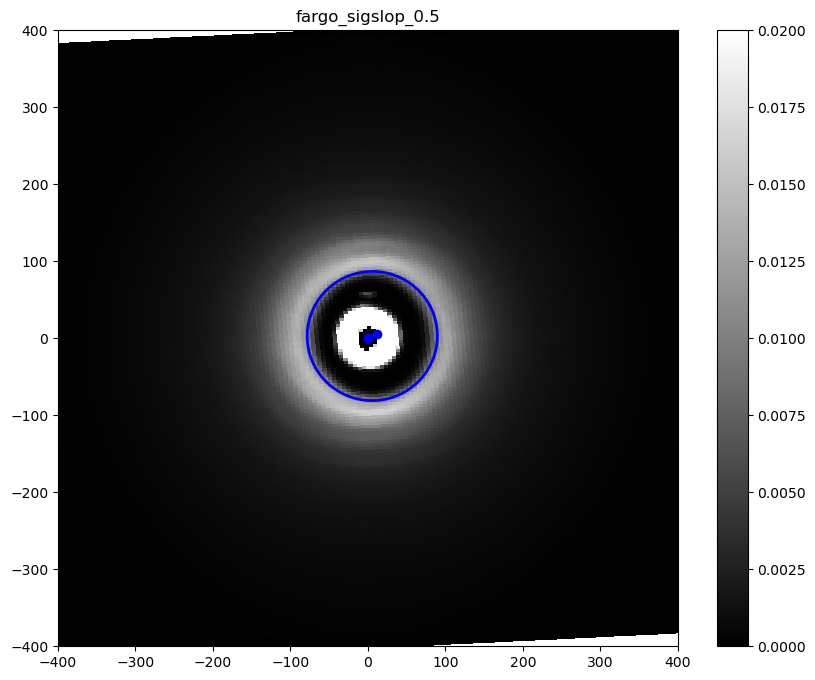

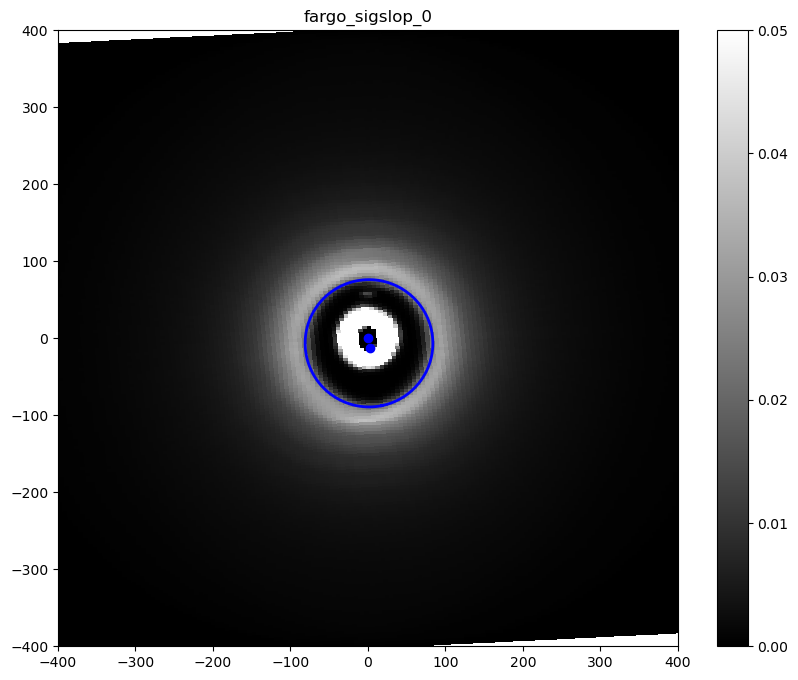

In [166]:

index_for_sigslop = [8,0,6,5]

r_in_log = [0.14,0.14,0.135,0.125]
r_out_log = [0.215,0.20,0.20,0.195]
phi_ellipse = [5.0-np.pi,4.9-np.pi,5.2-np.pi,0.2]


lim = 0.003

for it, i in enumerate(index_for_sigslop):
    plot_deprojected(np.power(10,log_img_data[i]), clim=(0,clim_up[i])) #clim=(lim-1e-4,lim+1e-4))#
    #plot_deprojected(log_img_data[i])
    
    plt.title(paths[i][43:-5])

    r_in = np.power(10,r_in_log[it])*57
    r_out = np.power(10,r_out_log[it])*57

    a = (r_in+r_out)/2
    e = (r_out-r_in)/2
    b = np.sqrt(a**2-e**2)
    print(f"r_in: {r_in}\nr_out: {r_out}")
    path = paths[i]
    print(f"Eccentricity for {path[43:-5]}: {e/a}")
    
    centerx = e
    centery = 0
    philist = np.linspace(0,2*np.pi,360)
    
    x_ell_ = centerx + a*np.cos(philist)
    y_ell_ = centery + b*np.sin(philist)
    
    phi = phi_ellipse[it]-np.pi/2
    x_ell = x_ell_*np.cos(phi) - y_ell_*np.sin(phi)
    y_ell = +x_ell_*np.sin(phi) + y_ell_*np.cos(phi)
    
    plt.plot(x_ell,y_ell, linewidth=2, color="blue")
    plt.scatter([0,2*e*np.cos(phi)],[0,2*e*np.sin(phi)], zorder=3, color="blue")

# Again, now zoomed in